In [1]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, os
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'..')))
from getdist import plots, MCSamples
import getdist
import camb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython
print('GetDist Version: %s, Matplotlib version: %s'%(getdist.__version__, plt.matplotlib.__version__))

/home/andrewcats/anaconda3/envs/conda_andrea_g/lib/python3.9/site-packages/numpy/_core/getlimits.py:545: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


GetDist Version: 1.5.4, Matplotlib version: 3.9.2


### Extract DESI data
I extract data for DESI DR2 and then for DESI DR1

In [ ]:
# Read file with DESI data DR2
# Measurements of distances
df_val = pd.read_csv(
    "/home/andrewcats/tesi_magistrale/lcdm/points/desi_dr2_points/desi_gaussian_bao_ALL_GCcomb_mean.txt",
    sep='\s+',
    header=None,
    names=["z", "value", "quantity"],
    comment='#'
)

# Matrix of covariance
df_err = pd.read_csv(
    "/home/andrewcats/tesi_magistrale/lcdm/points/desi_dr2_points/desi_gaussian_bao_ALL_GCcomb_cov.txt",
    sep='\s+',
    header=None,
)

cov_matrix = df_err.values
errors = np.sqrt(np.diag(cov_matrix))

# Attach errors (in same order)
df_val["error"] = errors

# Check
# print all values:
print(df_val.values)
#print(df_val.head())
print(df_err.shape)

[[0.295 7.94167639 'DV_over_rs' 0.07609196324185624]
 [0.51 13.58758434 'DM_over_rs' 0.16836678472905517]
 [0.51 21.86294686 'DH_over_rs' 0.42886832478046216]
 [0.706 17.35069094 'DM_over_rs' 0.17993122074837373]
 [0.706 19.45534918 'DH_over_rs' 0.33387003159912393]
 [0.934 21.57563956 'DM_over_rs' 0.1617815860968114]
 [0.934 17.64149464 'DH_over_rs' 0.20104324858099562]
 [1.321 27.60085612 'DM_over_rs' 0.32455587500459765]
 [1.321 14.17602155 'DH_over_rs' 0.22455135092000672]
 [1.484 30.51190063 'DM_over_rs' 0.763557644844186]
 [1.484 12.81699964 'DH_over_rs' 0.5180117691713191]
 [2.33 8.631545674846294 'DH_over_rs' 0.10106245296844917]
 [2.33 38.988973961958784 'DM_over_rs' 0.5316820280957407]]
       z      value    quantity     error
0  0.295   7.941676  DV_over_rs  0.076092
1  0.510  13.587584  DM_over_rs  0.168367
2  0.510  21.862947  DH_over_rs  0.428868
3  0.706  17.350691  DM_over_rs  0.179931
4  0.706  19.455349  DH_over_rs  0.333870
(13, 13)
13


In [14]:
# DR2
# Transverse comoving distance
dm = df_val[df_val["quantity"] == "DM_over_rs"]

# Hubble distance
dh = df_val[df_val["quantity"] == "DH_over_rs"]

# Check:
print(dm)
print(dh)

        z      value    quantity     error
1   0.510  13.587584  DM_over_rs  0.168367
3   0.706  17.350691  DM_over_rs  0.179931
5   0.934  21.575640  DM_over_rs  0.161782
7   1.321  27.600856  DM_over_rs  0.324556
9   1.484  30.511901  DM_over_rs  0.763558
12  2.330  38.988974  DM_over_rs  0.531682
        z      value    quantity     error
2   0.510  21.862947  DH_over_rs  0.428868
4   0.706  19.455349  DH_over_rs  0.333870
6   0.934  17.641495  DH_over_rs  0.201043
8   1.321  14.176022  DH_over_rs  0.224551
10  1.484  12.817000  DH_over_rs  0.518012
11  2.330   8.631546  DH_over_rs  0.101062


In [4]:
# DR2
# Load best-fit parameters from file
#        weight    minuslogpost            logA              ns    theta_MC_100           ombh2           omch2             tau        A_planck         cal100A         cal100B         cal143B         cal217A         cal217B          Aradio          Adusty          AdustT      beta_dustT            Acib        beta_cib            Atsz            Aksz              xi          AdustP      beta_dustP               A              As           DHBBN             YHe             Y_p             age           clamp              H0          omegam        omegamh2             zre          sigma8            s8h5      s8omegamp5     s8omegamp25           rdrag      beta_dusty       chi2__BAO       chi2__CMB        chi2__SN   minuslogprior minuslogprior__0            chi2  chi2__sn.desy5 chi2__bao.desi_dr2.desi_bao_all chi2__planck_2018_lowl.TT chi2__planck_2020_lollipop.lowlB chi2__planck_2020_lollipop.lowlEB chi2__planck_2020_hillipop.TTTEEE
columns_lcdm = [
    "minuslogpost", "logA", "ns", "theta_MC_100", "ombh2", "omch2",
    "tau", "A_planck", "cal100A", "cal100B", "cal143B", "cal217A", "cal217B",
    "Aradio", "Adusty", "AdustT", "beta_dustT", "Acib", "beta_cib", "Atsz",
    "Aksz", "xi", "AdustP", "beta_dustP", "A", "As", "DHBBN", "YHe", "Y_p",
    "age", "clamp", "H0", "omegam", "omegamh2", "zre", "sigma8", "s8h5",
    "s8omegamp5", "s8omegamp25", "rdrag", "beta_dusty", "chi2__BAO",
    "chi2__CMB", "chi2__SN", "minuslogprior", "minuslogprior__0", "chi2",
    "chi2__sn.desy5", "chi2__bao.desi_dr2.desi_bao_all",
    "chi2__planck_2018_lowl.TT", "chi2__planck_2020_lollipop.lowlB",
    "chi2__planck_2020_lollipop.lowlEB", "chi2__planck_2020_hillipop.TTTEEE"
]

df = pd.read_csv("/home/andrewcats/tesi_magistrale/lcdm/planck_all/minimize/1_lcdm_planck_desidr2_des_min.minimum.txt", delim_whitespace=True, skiprows=1, names=columns_lcdm)

# Extract values
H0_best = df["H0"].values[0]
ombh2_best = df["ombh2"].values[0]
omch2_best = df["omch2"].values[0]
tau_best = df["tau"].values[0]
ns_best = df["ns"].values[0]
logA_best = df["logA"].values[0]
As_best = logA = df["As"].values[0]
rdrag_best = df["rdrag"].values[0]


# Now for DR2 EXP
#        weight    minuslogpost              H0            logA              ns           ombh2           omch2             tau      EFT_lambda        A_planck         cal100A         cal100B         cal143B         cal217A         cal217B          Aradio          Adusty          AdustT      beta_dustT            Acib        beta_cib            Atsz            Aksz              xi          AdustP      beta_dustP               A              As           DHBBN             YHe             Y_p             age           clamp        omega_de          omegam        omegamh2           rdrag            s8h5      S8_optimal     s8omegamp25      s8omegamp5          sigma8       thetastar            zrei      beta_dusty       chi2__BAO       chi2__CMB        chi2__SN   minuslogprior minuslogprior__0            chi2  chi2__sn.desy5 chi2__bao.desi_dr2.desi_bao_all chi2__planck_2018_lowl.TT chi2__planck_2020_lollipop.lowlB chi2__planck_2020_lollipop.lowlEB chi2__planck_2020_hillipop.TTTEEE
columns_exp = [
    "weight", "minuslogpost", "H0", "logA", "ns", "ombh2", "omch2",
    "tau", "EFT_lambda", "A_planck", "cal100A", "cal100B", "cal143B",
    "cal217A", "cal217B", "Aradio", "Adusty", "AdustT", "beta_dustT",
    "Acib", "beta_cib", "Atsz", "Aksz", "xi", "AdustP", "beta_dustP",
    "A", "As", "DHBBN", "YHe", "Y_p", "age", "clamp", "omega_de",
    "omegam", "omegamh2", "rdrag", "s8h5", "S8_optimal",
    "s8omegamp25", "s8omegamp5", "sigma8", "thetastar", "zrei",
    "beta_dusty", "chi2__BAO", "chi2__CMB", "chi2__SN",
    "minuslogprior", "minuslogprior__0", "chi2",
    "chi2__sn.desy5", "chi2__bao.desi_dr2.desi_bao_all",
    "chi2__planck_2018_lowl.TT", "chi2__planck_2020_lollipop.lowlB",
    "chi2__planck_2020_lollipop.lowlEB", "chi2__planck_2020_hillipop.TTTEEE"
]

df_exp = pd.read_csv("/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/planck_all/minimize/1_EXP_planck_desidr2_des_min.minimum.txt", delim_whitespace=True, skiprows=1, names=columns_exp)

# Extract values
H0_exp = df_exp["H0"].values[0]
ombh2_exp = df_exp["ombh2"].values[0]
omch2_exp = df_exp["omch2"].values[0]
tau_exp = df_exp["tau"].values[0]
ns_exp = df_exp["ns"].values[0]
logA_exp = df_exp["logA"].values[0]
As_exp = logA = df_exp["As"].values[0]
rdrag_exp = df_exp["rdrag"].values[0]


# Now for DR2 w0wa
#        weight    minuslogpost            logA              ns    theta_MC_100           ombh2           omch2             tau               w              wa        A_planck         cal100A         cal100B         cal143B         cal217A         cal217B          Aradio          Adusty          AdustT      beta_dustT            Acib        beta_cib            Atsz            Aksz              xi          AdustP      beta_dustP               A              As           DHBBN             YHe             Y_p             age           clamp              H0          omegam        omegamh2             zre          sigma8            s8h5      s8omegamp5     s8omegamp25           rdrag      beta_dusty       chi2__BAO       chi2__CMB        chi2__SN   minuslogprior minuslogprior__0            chi2  chi2__sn.desy5 chi2__bao.desi_dr2.desi_bao_all chi2__planck_2018_lowl.TT chi2__planck_2020_lollipop.lowlB chi2__planck_2020_lollipop.lowlEB chi2__planck_2020_hillipop.TTTEEE
columns_w0wa = [
    "weight", "minuslogpost", "logA", "ns", "theta_MC_100", "ombh2", "omch2",
    "tau", "w", "wa", "A_planck", "cal100A", "cal100B", "cal143B",
    "cal217A", "cal217B", "Aradio", "Adusty", "AdustT", "beta_dustT",
    "Acib", "beta_cib", "Atsz", "Aksz", "xi", "AdustP", "beta_dustP",
    "A", "As", "DHBBN", "YHe", "Y_p", "age", "clamp", "H0",
    "omegam", "omegamh2", "zre", "sigma8", "s8h5",
    "s8omegamp5", "s8omegamp25", "rdrag", "beta_dusty",
    "chi2__BAO", "chi2__CMB", "chi2__SN",
    "minuslogprior", "minuslogprior__0",
    # chi2
    'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all',
    'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB',
    'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE'
]

df_w0wa = pd.read_csv("/home/andrewcats/tesi_magistrale/w0wacdm/all_planck/minimize/1_w0wa_planck_desidr2_des_min.minimum.txt", delim_whitespace=True, skiprows=1, names=columns_w0wa) 

# Extract values
H0_w0wa = df_w0wa["H0"].values[0]
ombh2_w0wa = df_w0wa["ombh2"].values[0]
omch2_w0wa = df_w0wa["omch2"].values[0]
tau_w0wa = df_w0wa["tau"].values[0]
ns_w0wa = df_w0wa["ns"].values[0]
logA_w0wa = df_w0wa["logA"].values[0]
As_w0wa = logA = df_w0wa["As"].values[0]
rdrag_w0wa = df_w0wa["rdrag"].values[0]

/tmp/ipykernel_10791/1363165067.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("/home/andrewcats/tesi_magistrale/lcdm/planck_all/minimize/1_lcdm_planck_desidr2_des_min.minimum.txt", delim_whitespace=True, skiprows=1, names=columns_lcdm)
/tmp/ipykernel_10791/1363165067.py:47: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_exp = pd.read_csv("/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/planck_all/minimize/1_EXP_planck_desidr2_des_min.minimum.txt", delim_whitespace=True, skiprows=1, names=columns_exp)
/tmp/ipykernel_10791/1363165067.py:78: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_w0wa = pd.read_csv("/home/andrewcats/tesi_magistrale/w0wacdm

### Compute distances

In [5]:
# DR2
# Set CAMB parameters
pars = camb.CAMBparams()
pars.set_cosmology(H0=H0_best, ombh2=ombh2_best, omch2=omch2_best, tau=tau_best)
pars.InitPower.set_params(ns=ns_best, As=As_best)
pars.set_for_lmax(0)
pars.DoLensing = False
results_best = camb.get_results(pars)


# Initialize lists to store distances
dc_list_best = []
da_list_best = []
dl_list_best = []
dm_list_best = [] # comoving angular diameter distance
dh_list_best = [] # Hubble distance

c = 2.99792458e5 # speed of light in km/s
z = np.linspace(0, 3, 1000) # redshift range

for i in z:
    dc_list_best.append(results_best.comoving_radial_distance(i)/rdrag_best)
    da_list_best.append(results_best.angular_diameter_distance(i)/rdrag_best)
    dl_list_best.append(results_best.luminosity_distance(i)/rdrag_best)
    dh_list_best.append((c/results_best.hubble_parameter(i))/rdrag_best) # Hubble distance

# Convert lists to arrays
dc_rs_best = np.array(dc_list_best)
da_rs_best = np.array(da_list_best)
dl_rs_best = np.array(dl_list_best)
dh_rs_best = np.array(dh_list_best)

In [6]:
# DR2 EXP
# Compute distances

# Set CAMB parameters
pars_exp = camb.CAMBparams()
pars_exp.set_cosmology(H0=H0_exp, ombh2=ombh2_exp, omch2=omch2_exp, tau=tau_exp)
pars_exp.InitPower.set_params(ns=ns_exp, As=As_exp)
pars_exp.set_for_lmax(0)
pars_exp.DoLensing = False
results_exp = camb.get_results(pars_exp)

# Initialize lists to store distances
dc_list_exp = [] # comoving distance
#da_list_exp = []
#dl_list_exp = []
dm_list_exp = [] # comoving angular diameter distance
dh_list_exp = [] # Hubble distance

for i in z:
    dc_list_exp.append(results_exp.comoving_radial_distance(i)/rdrag_exp)
    #da_list_exp.append(results_exp.angular_diameter_distance(i)/rdrag_exp)
    #dl_list_exp.append(results_exp.luminosity_distance(i)/rdrag_exp)
    dh_list_exp.append((c/results_exp.hubble_parameter(i))/rdrag_exp)

# Convert lists to arrays
dc_rs_exp = np.array(dc_list_exp)
#da_rs_exp = np.array(da_list_exp)
#dl_rs_exp = np.array(dl_list_exp)
dh_rs_exp = np.array(dh_list_exp)

In [7]:
# DR2 w0wa
# Compute distances

# Set CAMB parameters
pars_w0wa = camb.CAMBparams()
pars_w0wa.set_cosmology(H0=H0_w0wa, ombh2=ombh2_w0wa, omch2=omch2_w0wa, tau=tau_w0wa)
pars_w0wa.InitPower.set_params(ns=ns_w0wa, As=As_w0wa)
pars_w0wa.set_for_lmax(0)
pars_w0wa.DoLensing = False
results_w0wa = camb.get_results(pars_w0wa)

# Initialize lists to store distances
dc_list_w0wa = [] # comoving distance
#da_list_w0wa = []
#dl_list_w0wa = []
dm_list_w0wa = [] # comoving angular diameter distance
dh_list_w0wa = [] # Hubble distance

for i in z:
    dc_list_w0wa.append(results_w0wa.comoving_radial_distance(i)/rdrag_w0wa)
    #da_list_w0wa.append(results_w0wa.angular_diameter_distance(i)/rdrag_w0wa)
    #dl_list_w0wa.append(results_w0wa.luminosity_distance(i)/rdrag_w0wa)
    dh_list_w0wa.append((c/results_w0wa.hubble_parameter(i))/rdrag_w0wa)

# Convert lists to arrays
dc_rs_w0wa = np.array(dc_list_w0wa)
#da_rs_w0wa = np.array(da_list_w0wa)
#dl_rs_w0wa = np.array(dl_list_w0wa)
dh_rs_w0wa = np.array(dh_list_w0wa)

Now, I make the residual plot

In [8]:
# Interpolate CAMB model onto DESI z
from scipy.interpolate import interp1d

# LCDM
# DR2 DM
dm_model_interp = interp1d(z, dc_rs_best, kind='cubic')
dm_model_at_dataz = dm_model_interp(dm["z"])
# Compute ratio and error
ratio = dm["value"] / dm_model_at_dataz
ratio_err = dm["error"] / dm_model_at_dataz

# DR2 DH
dh_model_interp = interp1d(z, dh_rs_best, kind='cubic')
dh_model_at_dataz = dh_model_interp(dm["z"])
# Compute ratio and error
ratio_dh = dh["value"] / dh_model_at_dataz
ratio_err_dh = dh["error"] / dh_model_at_dataz


#EXP
# DR2 DM
dm_model_interp_exp = interp1d(z, dc_rs_exp, kind='cubic')
dm_model_at_dataz_exp = dm_model_interp_exp(dm["z"])
# Compute ratio and error
ratio_exp = dm["value"] / dm_model_at_dataz_exp
ratio_err_exp = dm["error"] / dm_model_at_dataz_exp

# DR2 DH
dh_model_interp_exp = interp1d(z, dh_rs_exp, kind='cubic')
dh_model_at_dataz_exp = dh_model_interp_exp(dm["z"])
# Compute ratio and error
ratio_dh_exp = dh["value"] / dh_model_at_dataz_exp
ratio_err_dh_exp = dh["error"] / dh_model_at_dataz_exp


#W0WA
# DR2 DM
dm_model_interp_w0wa = interp1d(z, dc_rs_w0wa, kind='cubic')
dm_model_at_dataz_w0wa = dm_model_interp_w0wa(dm["z"])
# Compute ratio and error
ratio_w0wa = dm["value"] / dm_model_at_dataz_w0wa
ratio_err_w0wa = dm["error"] / dm_model_at_dataz_w0wa

# DR2 DH
dh_model_interp_w0wa = interp1d(z, dh_rs_w0wa, kind='cubic')
dh_model_at_dataz_w0wa = dh_model_interp_w0wa(dm["z"])
# Compute ratio and error
ratio_dh_w0wa = dh["value"] / dh_model_at_dataz_w0wa
ratio_err_dh_w0wa = dh["error"] / dh_model_at_dataz_w0wa

Plot of DM

Redshift values: [0.51  0.706 0.934 1.321 1.484 2.33 ]


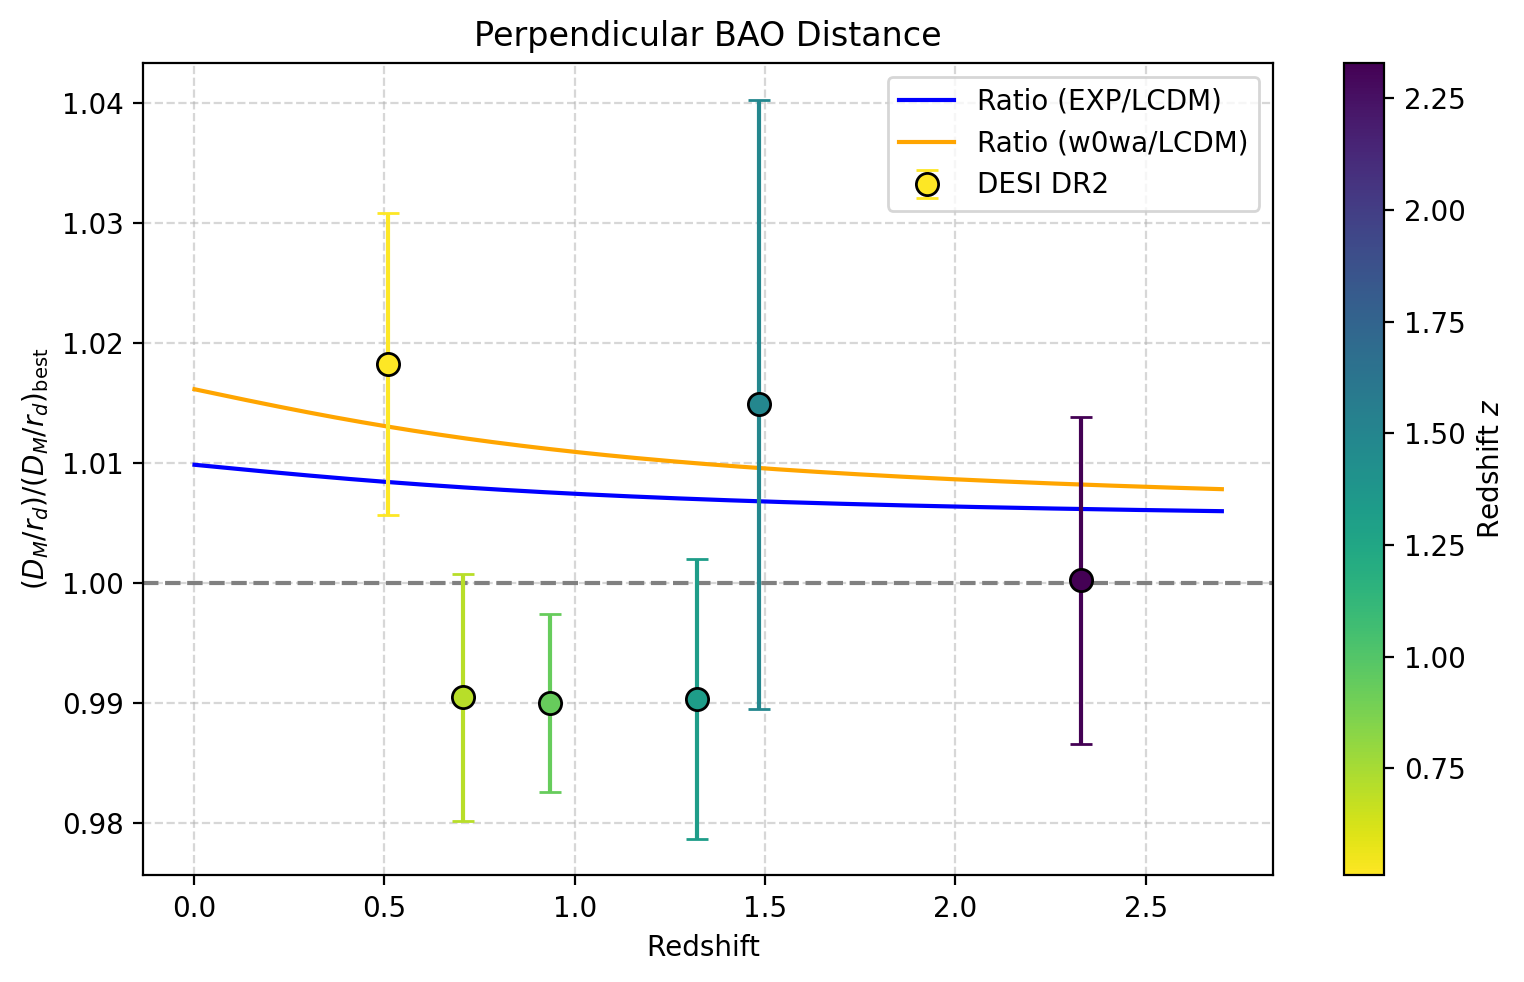

In [15]:
from matplotlib import cm

# Get values as arrays (DR2)
z_vals = dm["z"].to_numpy()
ratio = (dm["value"] / dm_model_at_dataz).to_numpy()
ratio_err = (dm["error"] / dm_model_at_dataz).to_numpy()
print("Redshift values:", z_vals)

# Normalize across full redshift range for consistent colormap
#all_z = np.concatenate([z_vals, z_vals_dr1])
norm = plt.Normalize(vmin=z_vals.min(), vmax=z_vals.max())
cmap = cm.viridis_r

colors_dr2 = cmap(norm(z_vals))
#colors_dr1 = cmap(norm(z_vals_dr1))

plt.figure(figsize=(8, 5))

# Plot DR2 points + error bars
for i in range(len(z_vals)):
    plt.errorbar(
        z_vals[i], ratio[i],
        yerr=ratio_err[i],
        fmt='o',
        markerfacecolor=colors_dr2[i],
        markeredgecolor='black',
        ecolor=colors_dr2[i],
        markersize=8,
        capsize=4,
        label='DESI DR2' if i == 0 else None,
        zorder=3
    )

# Plot DR1 points + error bars
'''
for i in range(len(z_vals_dr1)):
    plt.errorbar(
        z_vals_dr1[i], ratio_dr1[i],
        yerr=ratio_err_dr1[i],
        fmt='s',  # square marker to distinguish
        markerfacecolor=colors_dr1[i],
        markeredgecolor='black',
        ecolor=colors_dr1[i],
        markersize=8,
        capsize=4,
        label='DESI DR1' if i == 0 else None,
        zorder=2
    )
'''
# Colorbar for shared redshift
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
ax = plt.gca()
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Redshift $z$')

# Plot Distance(with exp or with w0wa)/Distance(with lcdm) vs redshift

# Compute ratio:
R_list_exp = [] # ratio between distances (exp/lcdm)
R_list_w0wa = [] # ratio between distances (w0wa/lcdm)

z_list = np.linspace(0.001, 2.7, 1000) # redshift range

for i in z_list:
    R_list_exp.append(results_exp.comoving_radial_distance(i) / results_best.comoving_radial_distance(i))
    R_list_w0wa.append(results_w0wa.comoving_radial_distance(i) / results_best.comoving_radial_distance(i))

R_exp = np.array(R_list_exp)
R_w0wa = np.array(R_list_w0wa)

plt.plot(z_list, R_exp, label='Ratio (EXP/LCDM)', color='blue')
plt.plot(z_list, R_w0wa, label='Ratio (w0wa/LCDM)', color='orange')

# Horizontal reference line
plt.axhline(1.0, color='gray', linestyle='--')

# Labels and aesthetics
plt.xlabel("Redshift ")
plt.ylabel(r"$(D_M/r_d) / (D_M/r_d)_{\rm best}$")
plt.title("Perpendicular BAO Distance")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Plot of DH

Redshift values: [0.51  0.706 0.934 1.321 1.484 2.33 ]


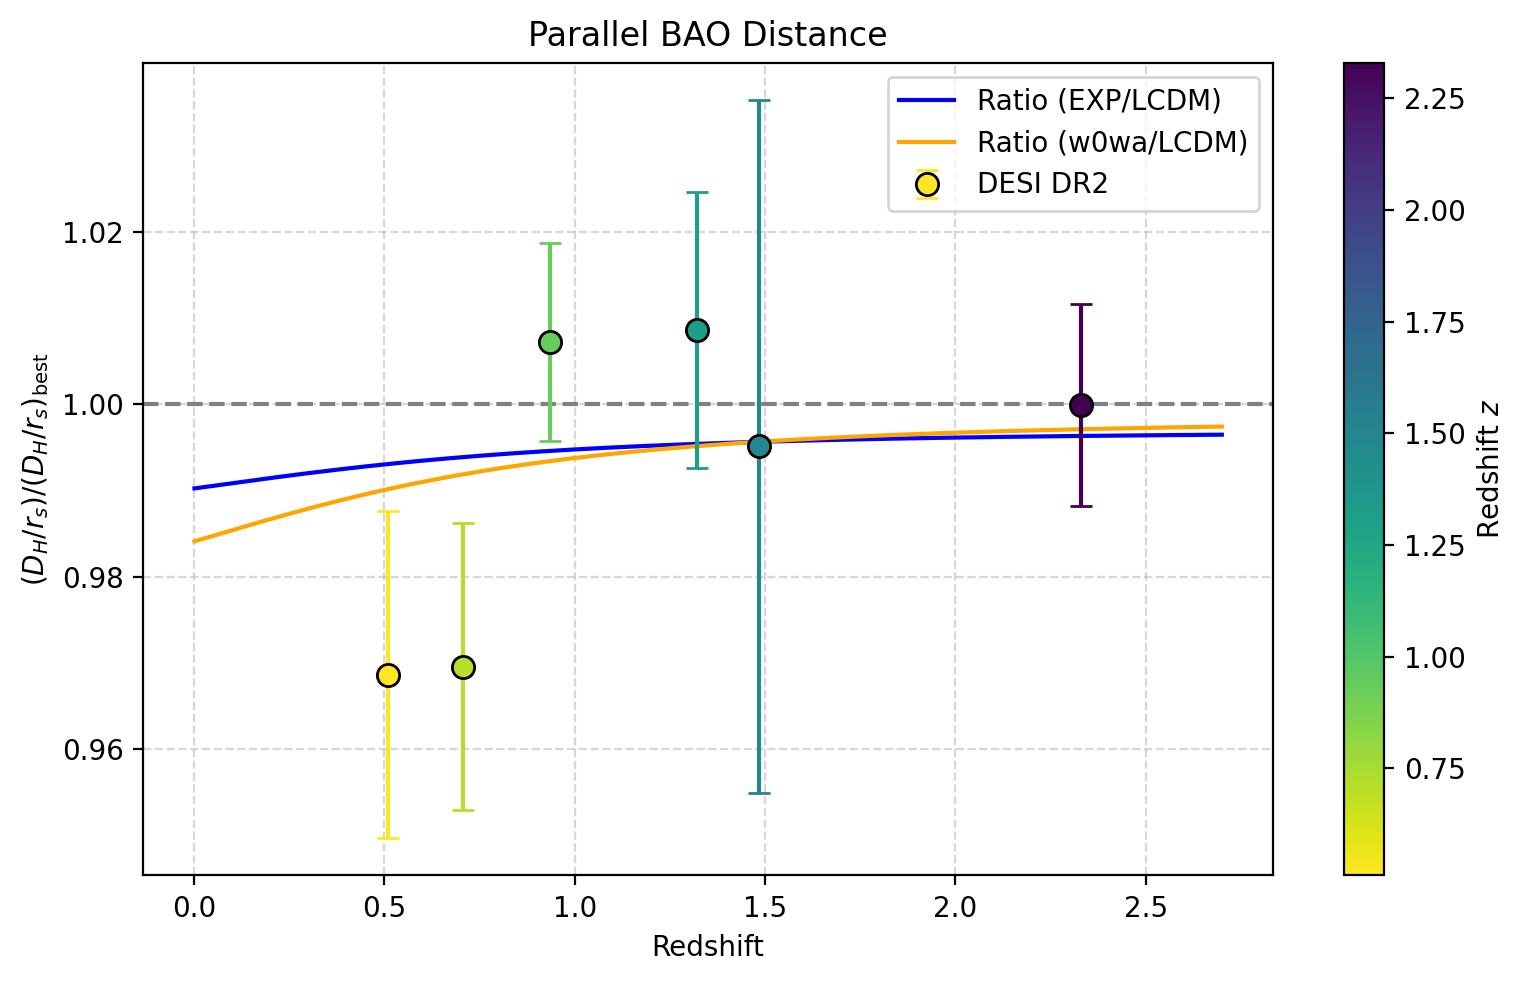

In [ ]:

# Get values as arrays (DR2)
z_vals_dh = dh["z"].to_numpy()
ratio_dh = (dh["value"] / dh_model_at_dataz).to_numpy()
ratio_err_dh = (dh["error"] / dh_model_at_dataz).to_numpy()
print("Redshift values:", z_vals_dh)

# Normalize across full redshift range for consistent colormap
#all_z = np.concatenate([z_vals, z_vals_dr1])
norm_dh = plt.Normalize(vmin=z_vals_dh.min(), vmax=z_vals_dh.max())
cmap_dh = cm.viridis_r

colors_dr2_dh = cmap_dh(norm(z_vals_dh))
#colors_dr1 = cmap(norm(z_vals_dr1))

plt.figure(figsize=(8, 5))

# Plot DR2 points + error bars
for i in range(len(z_vals_dh)):
    plt.errorbar(
        z_vals_dh[i], ratio_dh[i],
        yerr=ratio_err_dh[i],
        fmt='o',
        markerfacecolor=colors_dr2_dh[i],
        markeredgecolor='black',
        ecolor=colors_dr2_dh[i],
        markersize=8,
        capsize=4,
        label='DESI DR2' if i == 0 else None,
        zorder=3
    )

# Plot DR1 points + error bars
'''
for i in range(len(z_vals_dr1)):
    plt.errorbar(
        z_vals_dr1[i], ratio_dh_dr1[i],
        yerr=ratio_err_dh_dr1[i],
        fmt='s',  # square marker to distinguish
        markerfacecolor=colors_dr1[i],
        markeredgecolor='black',
        ecolor=colors_dr1[i],
        markersize=8,
        capsize=4,
        label='DESI DR1' if i == 0 else None,
        zorder=2
    )
'''

# Colorbar for shared redshift
sm_dh = cm.ScalarMappable(cmap=cmap_dh, norm=norm_dh)
sm_dh.set_array([])
ax_dh = plt.gca()
cbar_dh = plt.colorbar(sm_dh, ax=ax_dh)
cbar_dh.set_label('Redshift $z$')

# Plot Distance(with exp or with w0wa)/Distance(with lcdm) vs redshift

# Compute ratio:
R_list_exp_dh = [] # ratio between distances (exp/lcdm)
R_list_w0wa_dh = [] # ratio between distances (w0wa/lcdm)
for i in z_list:
    R_list_exp_dh.append(results_exp.hubble_parameter(i) / results_best.hubble_parameter(i))
    R_list_w0wa_dh.append(results_w0wa.hubble_parameter(i) / results_best.hubble_parameter(i))
R_exp_dh = np.array(R_list_exp_dh)
R_w0wa_dh = np.array(R_list_w0wa_dh)

plt.plot(z_list, R_exp_dh, label='Ratio (EXP/LCDM)', color='blue')
plt.plot(z_list, R_w0wa_dh, label='Ratio (w0wa/LCDM)', color='orange')

# Horizontal reference line
plt.axhline(1.0, color='gray', linestyle='--')

# Labels and aesthetics
plt.xlabel("Redshift")
plt.ylabel(r"$(D_H/r_d) / (D_H/r_d)_{\rm best}$")
plt.title("Parallel BAO Distance")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()